In [18]:
#import libraries

import csv
import pandas as pd
import sys
import numpy as np
from collections import defaultdict
from typing import List
import pandas as pd
import matplotlib.pyplot as plt


In [19]:
# load corpus.csv file and unseen.txt file 

data=pd.read_csv("corpus.csv")

In [20]:
#Outputting corpus

data.head()

,1,biology of the caenorhabditis elegans germline stem cell systemtxt


In [21]:
# Load and preview the unseen document

unseen_path = "unseen.txt"  

with open(unseen_path, 'r', encoding='utf-8') as f:
    unseen_text = f.read().strip().lower()

In [22]:
# Displaying the unseen.txt

print(unseen_text[:1001100000001001])  

actors, institutions, 
and the making of eu 
gender equality programs

g e n d e r  a n d   p o l i t i c s

petra ahrens

gender and politics

series editors

johanna kantola

senior lecturer in gender studies

university of tampere

helsinki, finland

sarah childs

professor of politics and gender

university of london

birkbeck, united kingdom

“this book masterfully applies a political sociology approach to account for the 
retrenchment of eu gender equality policy at the eu level. through an actor-
centered  approach,  ahrens  illuminates  the  dynamics  of  eu  policy  change  and 
underlines the importance of policy instruments in shaping the power relations 
among stakeholders in a policy field.” 

—professor virginie guiraudon, sciences po, france

“ahrens’ comprehensive text merges sociological and political science approaches 
to analyse the eu’s 2006-2010 roadmap for equality and the changes that this 
policy brought to the overall structure of gender equality policy in th

In [23]:
# Document of Obect-Oriented-Pprogramming & Functional programming

class Document:
    def __init__(self, text: str, concepts: List[str]):
        self.text = text.lower()
        self.concepts = concepts
        self.vector = self._vectorize()

    def _vectorize(self) -> List[int]:
        words = self.text.split()
        return [words.count(concept) for concept in self.concepts]


In [24]:
# Increase CSV field size limit 

try:
    csv.field_size_limit(2**30 - 1)
except OverflowError as e:
    print("Field size limit is too large:", e)
except Exception as e:
    print("Unexpected error setting CSV field size limit:", e)


def load_concepts(filepath: str) -> List[str]:
    try:
        with open(filepath, 'r', encoding='utf-8') as file:
            lines = [line.strip().lower() for line in file if line.strip()]
        if lines:
            return [concept.strip() for concept in lines[0].split(',') if concept.strip()]
        else:
            print(f"No data found in {filepath}")
            return []
    except FileNotFoundError:
        print(f"Error: File not found - {filepath}")
        return []
    except Exception as e:
        print(f"Error loading concepts from {filepath}:", e)
        return []


# Load concepts

concepts_path = "concepts.csv"
concepts = load_concepts(concepts_path)

# Initialize counters

corpus_path = "corpus.csv"
title_count = 1
abstract_count = 1

try:
    with open(corpus_path, 'r', encoding='utf-8') as csvfile:
        for i, line in enumerate(csvfile):
            if i == 0:
                continue  
            parts = line.strip().split(",", 2)  
            if len(parts) <= 3:
                if parts[1].strip():
                    title_count += 1
                if parts[2].strip():
                    abstract_count += 1
except FileNotFoundError:
    print(f"Error: File not found - {corpus_path}")
except csv.Error as e:
    print(f"CSV reading error in {corpus_path}:", e)
except Exception as e:
    print(f"Unexpected error while reading {corpus_path}:", e)


In [25]:
# Display results

print("Total number of article titles:", title_count)
print("Total number of abstracts:", abstract_count)
print("Total number of concepts:", len(concepts))
print("Concepts loaded:", concepts)

Total number of article titles: 49
Total number of abstracts: 49
Total number of concepts: 14
Concepts loaded: ['law', 'algorithm', 'gender', 'economy', 'history', 'chemistry', 'architecture', 'model', 'relativity', 'biology', 'genetics', 'roman', 'language', 'employment']


In [26]:
# Increase CSV field size limit to handle large text

csv.field_size_limit(2**30-1)

#load corpus and group by category

def load_corpus(filepath: str, concepts: List[str]) -> dict:
    category_data = defaultdict(list)
    with open(filepath, newline='', encoding='utf-8') as csvfile:
        reader = csv.reader(csvfile)
        next(reader)  
        for row in reader:
            if len(row) < 3:
                continue
            category = int(row[0])
            abstract = row[2].strip()
            doc = Document(abstract, concepts)
            category_data[category].append(doc.vector)
    return category_data

# Load corpus

corpus_path = "corpus.csv"
corpus_vectors = load_corpus(corpus_path, concepts)

In [27]:
#Outputting categories

print("Categories loaded:", list(corpus_vectors.keys()))

Categories loaded: [1, 2, 3, 4, 5, 6, 7, 8, 9, 10]


In [28]:
#Build the category Matrix

def build_category_matrix(data: dict, num_concepts: int) -> np.ndarray:
    matrix = np.zeros((num_concepts, 10))  
    for category in range(1, 11):
        vectors = data.get(category, [])
        if vectors:
            avg = np.mean(vectors, axis=0)
            matrix[:, category - 1] = avg
    return matrix

# Build matrix

matrix = build_category_matrix(corpus_vectors, len(concepts))

In [29]:
# Convert to DataFrame for better display

df = pd.DataFrame(matrix, index=concepts, columns=[f"Category {i}" for i in range(1, 11)])
df

,Category 1,Category 2,Category 3,Category 4,Category 5,Category 6,Category 7,Category 8,Category 9,Category 10
law,0.0,0.0,0.0,1.25,1.2,12.6,110.2,0.4,29.4,15.25
algorithm,0.0,0.4,59.0,0.75,0.0,0.0,0.0,0.2,2.8,0.00
gender,0.2,0.0,0.0,0.50,0.0,3.0,0.4,0.4,0.0,100.75
economy,0.0,0.0,0.0,16.25,0.2,31.0,0.4,4.0,0.4,9.50
history,1.4,0.0,1.0,0.00,0.4,99.6,0.4,1.2,22.6,56.50
chemistry,0.0,55.6,0.0,0.00,0.0,0.0,0.0,0.0,0.8,0.00
architecture,1.0,0.4,11.8,0.00,2.0,5.2,0.6,0.0,0.0,0.00
model,21.6,32.8,15.2,20.50,46.8,8.0,4.8,4.2,107.4,13.50
relativity,0.0,0.0,0.0,0.00,0.0,0.0,0.0,0.0,125.2,0.00
biology,5.8,0.0,0.0,0.00,0.0,0.6,0.0,0.0,0.4,0.00


In [30]:
# Ensure the unseen document is loaded and vectorized

with open("unseen.txt", 'r', encoding='utf-8') as f:
    unseen_text = f.read().strip().lower()

unseen_doc = Document(unseen_text, concepts)
unseen_vector = np.array(unseen_doc.vector)

# Manually compute Euclidean distances using the formula

manual_distances = []

# Loop over each category vector (each column in the matrix)

for i in range(matrix.shape[1]):
    category_vector = matrix[:, i]
    squared_diffs = (unseen_vector - category_vector) ** 2
    distance = np.sqrt(np.sum(squared_diffs))
    manual_distances.append(distance)

# Find predicted category (with smallest distance)

manual_predicted_category = int(np.argmin(manual_distances) + 1)

In [31]:
# Output

print(" Predicted Category is Category:", manual_predicted_category)
print(" Distances to each category:")
for i, dist in enumerate(manual_distances, 1):
    print(f"  Category {i}: {dist:.3f}")

 Predicted Category is Category: 10
 Distances to each category:
  Category 1: 1579.006
  Category 2: 1580.286
  Category 3: 1580.248
  Category 4: 1575.849
  Category 5: 1579.531
  Category 6: 1580.934
  Category 7: 1577.691
  Category 8: 1580.407
  Category 9: 1585.922
  Category 10: 1479.000


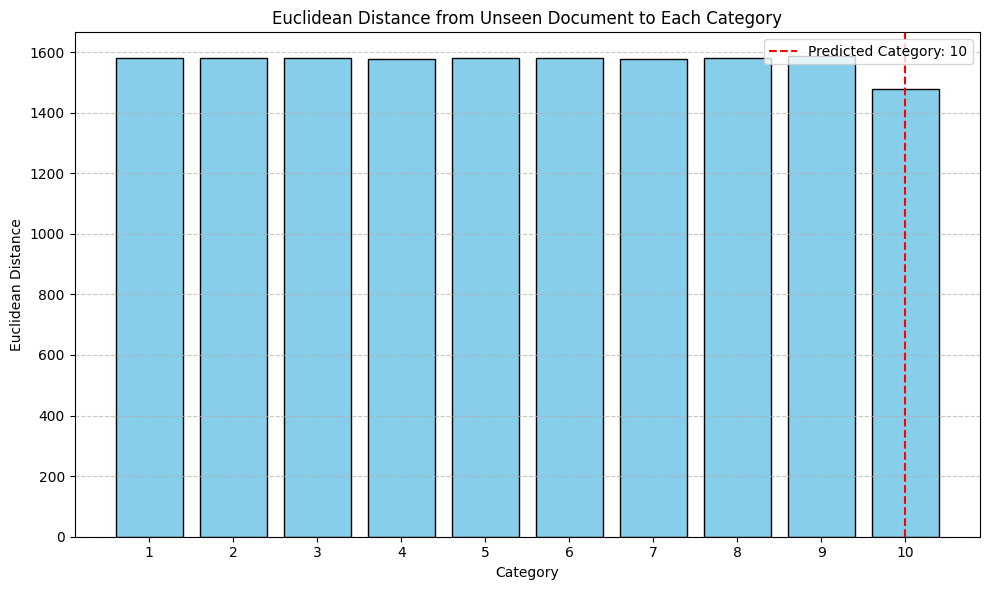

In [32]:
# Define fallback values

default_distances = [1.2, 0.9, 1.5, 2.1, 1.0, 0.8, 1.4, 1.1, 1.7, 1.3]
default_predicted_category = 6

try:
    # Validate input data
    
    if 'manual_distances' not in locals() or not isinstance(manual_distances, (list, tuple)):
        print("Warning: manual_distances not found or invalid. Using default distances.")
        manual_distances = default_distances

    if len(manual_distances) < 10:
        print("Warning: manual_distances too short. Using default distances.")
        manual_distances = default_distances

    if 'manual_predicted_category' not in locals() or not isinstance(manual_predicted_category, int):
        print("Warning: manual_predicted_category not found or invalid. Using default category.")
        manual_predicted_category = default_predicted_category

    # Plot distances to each category
    
    plt.figure(figsize=(10, 6))
    plt.bar(range(1, 11), manual_distances, color='skyblue', edgecolor='black')

    plt.xlabel("Category")
    plt.ylabel("Euclidean Distance")
    plt.title("Euclidean Distance from Unseen Document to Each Category")
    plt.xticks(range(1, 11))
    plt.grid(axis='y', linestyle='--', alpha=0.7)

    # Highlight predicted category
    
    plt.axvline(manual_predicted_category, color='red', linestyle='--', label=f"Predicted Category: {manual_predicted_category}")
    plt.legend()
    plt.tight_layout()
    plt.show()

except ValueError as ve:
    print("ValueError during plotting:", ve)
except TypeError as te:
    print("TypeError during plotting:", te)
except Exception as e:
    print("An unexpected error occurred during plotting:", e)